# Imports

In [1]:
import sys

repo_path = '/Users/zohairshafi/Local Workspace/spectral_nature/'
sys.path.append(repo_path)
from src.utils.alpaca_utils import *
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve


from datetime import datetime
from multiprocessing import Pool, cpu_count
import multiprocessing as mp
import pickle as pkl
from functools import partial
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA


with open(os.path.join(cache_path, 'headers.pkl'), 'rb') as file: 
    headers, paper_header = pkl.load(file)



# Data Collection

In [ ]:
# Import the worker function from a top-level module so it's picklable by child processes
from src.utils.run_symbol_worker import run_symbol

symbol_list = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'PINS', 'NVDA', 'QCOM']

# Progress logging setup
repo_path = '/Users/zohairshafi/Local Workspace/spectral_nature/'
progress_log_path = os.path.join(repo_path, 'cache', 'progress.log')
# Initialize/clear previous log
with open(progress_log_path, 'w') as _f:
    _f.write(f'Progress log started {datetime.utcnow().isoformat()}Z\n')

def log_progress(message: str):
    timestamp = datetime.utcnow().isoformat()
    with open(progress_log_path, 'a') as f:
        f.write(f'[{timestamp}] {message}\n')

# Ensure spawn start method (safer on macOS / notebooks)
try:
    mp.set_start_method('spawn', force=False)
except RuntimeError:
    # Already set in this interpreter
    pass

# Multiprocessing execution block
summaries = []

max_workers = min(8, cpu_count(), len(symbol_list))  # adjust as desired
log_progress(f'Launching process pool max_workers={max_workers} total_symbols={len(symbol_list)}')

with Pool(processes=max_workers) as pool:
    # Bind constant args for each worker using partial (picklable since function is module-level)
    worker_fn = partial(run_symbol, repo_path=repo_path, progress_log_path=progress_log_path)
    total = len(symbol_list)
    for completed, summary in enumerate(pool.imap_unordered(worker_fn, symbol_list), 1):
        summaries.append(summary)
        sym = summary.get('symbol', 'UNKNOWN')
        log_progress(f'COMPLETED symbol={sym} ({completed}/{total})')
        if completed % 2 == 0 or completed == total:
            pct = (completed/total)*100
            log_progress(f'OVERALL progress={completed}/{total} ({pct:0.1f}%)')

summary_df = pd.DataFrame(summaries)

display(summary_df)
print(f'Progress log written to: {progress_log_path}')

KeyboardInterrupt: 

# Data Pre-Processing

In [2]:
symbol_list = ['AAPL', 'MSFT', 'QCOM', 'GOOGL', 'AMZN', 'TSLA', 'PINS', 'NFLX', 'NVDA', 'META', 'SPY', 'QQQ']
data = []
for symbol in tqdm(symbol_list):
    with open(os.path.join(cache_path, 'closed_trades', f'{symbol}_closed_trades.pkl'), 'rb') as file: 
        closed_trades_df = pkl.load(file)
        closed_trades_df['Symbol'] = symbol
        data.append(closed_trades_df)
final_closed_trades_df = pd.concat(data).reset_index(drop = True)

final_closed_trades_df

  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 58.21it/s]


,entry_date,entry_credit,entry_stock_price,strike,IV Short,IV Long,Delta_Short,Delta_Long,Gamma Short,Gamma Long,...,spread_distance,current_date,return_pct,short_exit_reason,short_exit_date,long_exit_reason,long_exit_date,exit_date,final_pnl,Symbol
0,2024-01-18 05:00:00+00:00,-267.0,188.70,190.0,0.279893,0.225208,0.472493,0.495347,0.038545,0.030355,...,21,2024-02-23 05:00:00+00:00,-1.460674,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-390.0,AAPL
1,2024-01-18 05:00:00+00:00,-189.0,188.70,195.0,0.267601,0.216161,0.284047,0.343305,0.034320,0.029147,...,21,2024-02-23 05:00:00+00:00,-1.190476,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-225.0,AAPL
2,2024-01-18 05:00:00+00:00,-162.0,188.70,180.0,0.293569,0.239996,-0.190367,-0.235592,0.025015,0.021924,...,21,2024-02-23 05:00:00+00:00,-1.697531,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-275.0,AAPL
3,2024-01-18 05:00:00+00:00,-117.0,188.70,175.0,0.308609,0.253223,-0.096354,-0.147773,0.014962,0.015590,...,21,2024-02-23 05:00:00+00:00,-1.410256,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-165.0,AAPL
4,2024-01-19 05:00:00+00:00,-225.0,191.55,195.0,0.269282,0.211442,0.383161,0.424646,0.039276,0.031737,...,21,2024-02-23 05:00:00+00:00,-1.160000,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-261.0,AAPL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016981,2025-03-07 05:00:00+00:00,-98.0,491.74,530.0,0.359225,0.198158,0.002587,0.076181,0.000613,0.005862,...,21,2025-03-31 04:00:00+00:00,-1.000000,Short Expired,2025-03-10 00:00:00+00:00,Long Expired,2025-03-31 00:00:00+00:00,2025-03-31 04:00:00+00:00,-98.0,QQQ
1016982,2025-03-07 05:00:00+00:00,-154.0,491.74,525.0,0.317934,0.202269,0.002893,0.112302,0.000766,0.007651,...,21,2025-03-31 04:00:00+00:00,-1.000000,Short Expired,2025-03-10 00:00:00+00:00,Long Expired,2025-03-31 00:00:00+00:00,2025-03-31 04:00:00+00:00,-154.0,QQQ
1016983,2025-03-07 05:00:00+00:00,-98.0,491.74,530.0,0.292925,0.198158,0.002590,0.076181,0.000614,0.005862,...,20,2025-03-31 04:00:00+00:00,-1.000000,Short Expired,2025-03-11 00:00:00+00:00,Long Expired,2025-03-31 00:00:00+00:00,2025-03-31 04:00:00+00:00,-98.0,QQQ
1016984,2025-03-07 05:00:00+00:00,-240.0,491.74,520.0,0.296714,0.204873,0.005819,0.155739,0.001534,0.009462,...,21,2025-03-31 04:00:00+00:00,-1.004167,Short Expired,2025-03-10 00:00:00+00:00,Long Expired,2025-03-31 00:00:00+00:00,2025-03-31 04:00:00+00:00,-241.0,QQQ


In [3]:
data = {
    'Delta Long' : final_closed_trades_df['Delta_Long'],
    'Delta Short' : final_closed_trades_df['Delta_Short'],
    'Delta Ratio' : final_closed_trades_df['Delta_Long'] / final_closed_trades_df['Delta_Short'],
    'Delta Difference' : final_closed_trades_df['Delta_Long'] - final_closed_trades_df['Delta_Short'],
    'Gamma Long' : final_closed_trades_df['Gamma Long'],
    'Gamma Short' : final_closed_trades_df['Gamma Short'],
    'Gamma Difference' : final_closed_trades_df['Gamma Long'] - final_closed_trades_df['Gamma Short'],
    'Gamma Ratio' : final_closed_trades_df['Gamma Long'] / final_closed_trades_df['Gamma Short'],
    'IV Long' : final_closed_trades_df['IV Long'],
    'IV Short' : final_closed_trades_df['IV Short'],
    'IV Difference' : final_closed_trades_df['IV Long'] - final_closed_trades_df['IV Short'],
    'IV Ratio' : final_closed_trades_df['IV Long'] / final_closed_trades_df['IV Short'],
    'Theta Long' : final_closed_trades_df['Theta Long'],
    'Theta Short' : final_closed_trades_df['Theta Short'],
    'Theta Difference' : final_closed_trades_df['Theta Long'] - final_closed_trades_df['Theta Short'],
    'Theta Ratio' : final_closed_trades_df['Theta Long'] / final_closed_trades_df['Theta Short'],
    'Vega Long' : final_closed_trades_df['Vega Long'],
    'Vega Short' : final_closed_trades_df['Vega Short'],
    'Vega Difference': final_closed_trades_df['Vega Long'] - final_closed_trades_df['Vega Short'],
    'Vega Ratio' : final_closed_trades_df['Vega Long'] / final_closed_trades_df['Vega Short'],
    'Forward Factor' : final_closed_trades_df['forward_factor'],
    'Spread' : final_closed_trades_df['spread_distance'],
    'Short DTE': (final_closed_trades_df['current_date'] - final_closed_trades_df['short_expiry']).dt.days,
    'Strike Deviation' : 100 * np.abs(final_closed_trades_df['entry_stock_price'] - final_closed_trades_df['strike']) / final_closed_trades_df['strike'],
    'PnL' : final_closed_trades_df['final_pnl'],
    'PnL Percent' : [-1 if x <= -1 else x for x in final_closed_trades_df['return_pct']],
    'Option Type' : [1 if x == 'call' else 0 for x in final_closed_trades_df['option_type']],
    'Symbol' : final_closed_trades_df['Symbol'], 
    # 'Day of Year': final_closed_trades_df['entry_date'].dt.dayofyear,
}

data = pd.DataFrame(data)
display (data)


,Delta Long,Delta Short,Delta Ratio,Delta Difference,Gamma Long,Gamma Short,Gamma Difference,Gamma Ratio,IV Long,IV Short,...,Vega Difference,Vega Ratio,Forward Factor,Spread,Short DTE,Strike Deviation,PnL,PnL Percent,Option Type,Symbol
0,0.495347,0.472493,1.048369,0.022854,0.030355,0.038545,-0.008190,0.787518,0.225208,0.279893,...,8.453479,1.559146,55.725466,21,21,0.684211,-390.0,-1.0,1,AAPL
1,0.343305,0.284047,1.208621,0.059258,0.029147,0.034320,-0.005173,0.849276,0.216161,0.267601,...,8.855018,1.687717,54.150627,21,21,3.230769,-225.0,-1.0,1,AAPL
2,-0.235592,-0.190367,1.237564,-0.045224,0.021924,0.025015,-0.003091,0.876444,0.239996,0.293569,...,7.863194,1.761895,49.535743,21,21,4.833333,-275.0,-1.0,0,AAPL
3,-0.147773,-0.096354,1.533642,-0.051419,0.015590,0.014962,0.000628,1.041955,0.253223,0.308609,...,7.152692,2.102501,48.177034,21,21,7.828571,-165.0,-1.0,0,AAPL
4,0.424646,0.383161,1.108272,0.041485,0.031737,0.039276,-0.007539,0.808052,0.211442,0.269282,...,8.958227,1.630299,62.398371,21,21,1.769231,-261.0,-1.0,1,AAPL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016981,0.076181,0.002587,29.453009,0.073595,0.005862,0.000613,0.005249,9.566936,0.198158,0.359225,...,17.640312,52.252608,104.964739,21,21,7.218868,-98.0,-1.0,1,QQQ
1016982,0.112302,0.002893,38.818521,0.109409,0.007651,0.000766,0.006885,9.988094,0.202269,0.317934,...,23.578996,62.920903,69.502587,21,21,6.335238,-154.0,-1.0,1,QQQ
1016983,0.076181,0.002590,29.417931,0.073591,0.005862,0.000614,0.005247,9.544218,0.198158,0.292925,...,17.582944,44.787519,63.023174,20,20,7.218868,-98.0,-1.0,1,QQQ
1016984,0.155739,0.005819,26.761916,0.149919,0.009462,0.001534,0.007928,6.167144,0.204873,0.296714,...,29.298336,42.168955,53.047531,21,21,5.434615,-241.0,-1.0,1,QQQ


(1005478, 25)

In [4]:
# 1) Build features and target (binary: positive PnL)
feature_cols = [c for c in data.columns
                if c not in ['PnL', 'PnL Percent', 'Symbol']
                and pd.api.types.is_numeric_dtype(data[c])]

# Assemble modeling frame and clean
df_model = data[feature_cols + ['PnL', 'PnL Percent']].copy()
df_model['label'] = (df_model['PnL'] > 0).astype(int)
df_model['regression_label'] = data['PnL Percent']
df_model = df_model.drop(columns=['PnL', 'PnL Percent'])
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()

# Stabilize range of regression target by removing outliers
df_model = df_model[(df_model['regression_label'] <= -0.1) |
                    (df_model['regression_label'] >= 0.1)]

X = df_model[feature_cols].to_numpy(dtype=np.float32)
y = df_model['label'].to_numpy(dtype=np.int64)
y_reg = df_model['regression_label'].to_numpy(dtype=np.float32)

test_size = 0.2
random_state = 42

X_train, X_test, y_train, y_test, y_reg_train, y_reg_test = train_test_split(X,
                                                    y,
                                                    y_reg,
                                                    test_size=test_size,
                                                    random_state=random_state,
                                                    stratify=y)


# 3) Standardize using train statistics (manual, no sklearn dependency)
mean_ = X_train.mean(axis = 0)
std_ = X_train.std(axis = 0) + 1e-8
X_train = (X_train - mean_) / std_
X_test = (X_test - mean_) / std_

min_reg_scale = np.min(y_reg_train)
denom_reg_scale = np.ptp(y_reg_train) + 1e-8

y_reg_train = (y_reg_train - min_reg_scale) / denom_reg_scale
y_reg_test = (y_reg_test - min_reg_scale) / denom_reg_scale
zero_point = (0 - min_reg_scale) / denom_reg_scale

# Inverse transform: scaled -> original units
def invert_reg_scale(x, denom_reg_scale, min_reg_scale):
    return x * denom_reg_scale + min_reg_scale

# 4) Build PyTorch datasets and loaders
batch_size = 100000
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train.astype(np.float32)), torch.from_numpy(y_reg_train.astype(np.float32)))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test.astype(np.float32)), torch.from_numpy(y_reg_test.astype(np.float32)))
train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_ds, batch_size = batch_size, shuffle = False)


In [7]:
class AutoEncoder(nn.Module):

    def __init__(self, in_dim, hidden_dim = 256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, in_dim)
        )

    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


class MultiModel(nn.Module):

    def __init__(self, in_dim, hidden_dim = 256):
        super().__init__()
        self.lin_one = nn.Linear(in_dim, hidden_dim)
        self.lin_two = nn.Linear(hidden_dim, hidden_dim)
        self.lin_three = nn.Linear(hidden_dim, hidden_dim)
        self.lin_four = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, 2)
        self.dropout = nn.Dropout(p = 0.1)

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.bn4 = nn.BatchNorm1d(hidden_dim)

    def forward(self, x):

        out = torch.relu(self.lin_one(x))
        out = self.bn1(out)
        out_one = self.dropout(out)

        out = torch.relu(self.lin_two(out_one))
        out = self.bn2(out) + out_one # Residual connection
        out_two = self.dropout(out) 

        out = torch.relu(self.lin_three(out_two))
        out = self.bn3(out) + out_two # Residual connection
        out_three = self.dropout(out)

        out = torch.relu(self.lin_four(out_three))
        out = self.bn4(out) + out_three # Residual connection
        out_four = self.dropout(out)
        
        return self.out(out_four)


In [8]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model = MultiModel(in_dim = X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 5e-4)

ae_model = AutoEncoder(in_dim = X_train.shape[1], hidden_dim = 256).to(device)
ae_optimizer = torch.optim.Adam(ae_model.parameters(), lr = 5e-4)
ae_criterion = nn.MSELoss()

# Handle class imbalance via pos_weight in BCEWithLogitsLoss
pos = float((y_train > 0.5).sum())
neg = float((y_train <= 0.5).sum())

pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight = pos_weight)

def mean_absolute_error(y_pred, y_true):

    reg_weights = torch.ones_like(y_true, device=device)
    reg_weights[y_true >= zero_point] = pos_weight

    return torch.mean(torch.abs(y_pred - y_true) * reg_weights)

criterion_regression = mean_absolute_error



Epoch 001 | Loss = 12.9116 | Train_acc = 0.509 | Train_MAE = 0.5000 | Train_Corr = 0.002

Epoch 005 | Loss = 4.8571 | Train_acc = 0.633 | Train_MAE = 0.2619 | Train_Corr = 0.011

Epoch 010 | Loss = 3.0716 | Train_acc = 0.661 | Train_MAE = 0.1670 | Train_Corr = 0.011

Epoch 015 | Loss = 1.9826 | Train_acc = 0.681 | Train_MAE = 0.1046 | Train_Corr = 0.019

Epoch 020 | Loss = 1.1705 | Train_acc = 0.693 | Train_MAE = 0.0577 | Train_Corr = 0.037

Epoch 025 | Loss = 0.5918 | Train_acc = 0.704 | Train_MAE = 0.0235 | Train_Corr = 0.055

Epoch 030 | Loss = 0.3569 | Train_acc = 0.711 | Train_MAE = 0.0097 | Train_Corr = 0.198

Epoch 035 | Loss = 0.3359 | Train_acc = 0.715 | Train_MAE = 0.0091 | Train_Corr = 0.189

Epoch 040 | Loss = 0.3354 | Train_acc = 0.720 | Train_MAE = 0.0124 | Train_Corr = 0.128

Epoch 045 | Loss = 0.3308 | Train_acc = 0.723 | Train_MAE = 0.0085 | Train_Corr = 0.237

Epoch 050 | Loss = 0.3298 | Train_acc = 0.725 | Train_MAE = 0.0086 | Train_Corr = 0.226

Epoch 055 | Loss = 

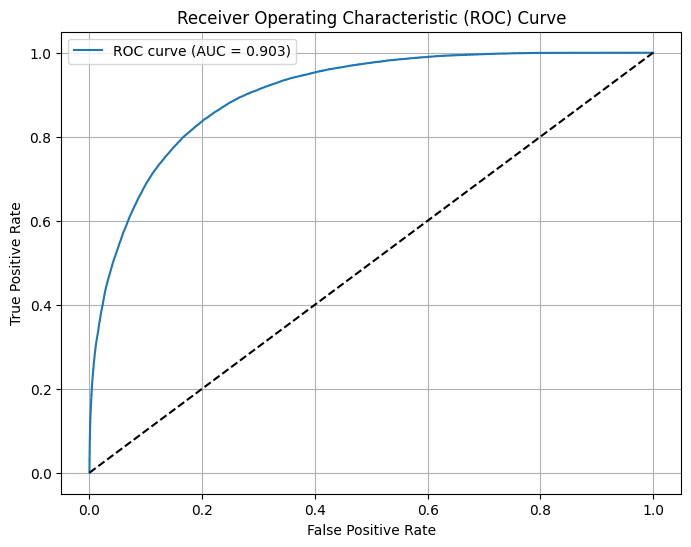

Precision: 0.465  Recall: 0.840  F1: 0.598


In [9]:
epochs = 500
patience = 5  # epochs to wait for improvement
min_delta = 1e-4  # minimum change to qualify as improvement
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    for xb, yb, yb_reg in train_loader:
        
        xb = xb.to(device)
        yb = yb.to(device).flatten()
        yb_reg = yb_reg.to(device).flatten()

        optimizer.zero_grad()    
        logits = model(xb)
        loss = criterion(logits[:, 0], yb)
        reg_loss = criterion_regression(logits[:, 1], yb_reg)
        total_loss = (0.1 * loss) + (10 * reg_loss)
        total_loss.backward()
        optimizer.step()

        # ae_optimizer.zero_grad()
        # decoded = ae_model(xb)
        # ae_loss = ae_criterion(decoded, xb)
        # ae_loss.backward()
        # ae_optimizer.step()

        running_loss += total_loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    if epoch % 5 == 0 or epoch == 1:
        with torch.no_grad():
            logits = model(torch.from_numpy(X_train).to(device))
            preds = (torch.sigmoid(logits[:, 0]).cpu().numpy().ravel() >= 0.5).astype(int)
            acc = (preds == y_train).mean() if len(y_train) else float('nan')
            mae = torch.mean(torch.abs(logits[:, 1].cpu() - torch.from_numpy(y_reg_train))).item()
            corr = np.corrcoef(logits[:, 1].cpu().numpy().ravel(), y_reg_train)[0, 1]

        print(f'\nEpoch {epoch:03d} | Loss = {epoch_loss:.4f} | Train_acc = {acc:.3f} | Train_MAE = {mae:.4f} | Train_Corr = {corr:.3f}')

    # ----- Validation (for early stopping) -----
#     model.eval()
#     val_running_loss = 0.0
#     acc = []
#     with torch.no_grad():
#         for xb, yb, yb_reg in test_loader:
#             xb = xb.to(device)
#             yb = yb.to(device).flatten()
#             yb_reg = yb_reg.to(device).flatten()
#             logits = model(xb)
#             v_loss_cls = criterion(logits[:, 0], yb)
#             v_loss_reg = criterion_regression(logits[:, 1], yb_reg)
#             val_running_loss += (v_loss_cls + v_loss_reg).item() * xb.size(0)
#             preds_test = (torch.sigmoid(logits[:, 0]).cpu().numpy().ravel() >= 0.5).astype(int)
#             acc.append((preds_test == yb.detach().cpu().numpy()).mean() if len(yb) else float('nan'))
#     val_loss = val_running_loss / len(test_loader.dataset)
#     print (f'Epoch {epoch:03d} | Loss = {total_loss.item():.4f} | Classification Loss: {loss.item():.4f} | Regression Loss: {reg_loss.item():.4f} | Test Accuracy: {np.mean(np.array(acc))}', end='\r')

#     # Check improvement
#     if val_loss < (best_val_loss - min_delta):
#         best_val_loss = val_loss
#         best_state = copy.deepcopy(model.state_dict())
#         epochs_no_improve = 0
#     else:
#         epochs_no_improve += 1
#         if epochs_no_improve >= patience:
#             print(f'Early stopping at epoch {epoch} (no improvement for {patience} epochs). Best val loss: {best_val_loss:.4f}')
#             break

# # Restore best model (if captured)
# if best_state is not None:
#     model.load_state_dict(best_state)

# 7) Evaluate on test set
model.eval()
with torch.no_grad():
    logits = model(torch.from_numpy(X_test).to(device))
    probs = torch.sigmoid(logits[:, 0]).cpu().numpy().ravel()
    y_pred = (probs >= 0.5).astype(int)
    y_reg_pred = logits[:, 1].cpu().numpy().ravel()
test_acc = (y_pred == y_test).mean() if len(y_test) else float('nan')
reg_test_mae = torch.mean(torch.abs(torch.tensor(y_reg_pred) - torch.tensor(y_reg_test))).item() if len(y_reg_test) else float('nan')
print(f'Test regression MAE: {reg_test_mae:.4f}')
print(f'Test accuracy: {test_acc:.3f}  (n_test={len(y_test)})')


roc_auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()

# Precision, Recall, F1
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
print(f'Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}')

# # Show learned weights with feature names
# coef = model.linear.weight[0].detach().cpu().numpy().ravel()
# bias = float(model.linear.bias[0].detach().cpu().numpy().ravel())

# coef_reg = model.linear.weight[1].detach().cpu().numpy().ravel()
# bias_reg = float(model.linear.bias[1].detach().cpu().numpy().ravel())

# coef_table = pd.DataFrame({'Features': feature_cols, 'Classification Weights': coef, 'Regression Weights': coef_reg}).sort_values('Classification Weights', ascending=False).reset_index(drop=True)
# print('Bias:', bias)
# print('Regression Bias:', bias_reg)
# display(coef_table)


In [12]:
torch.save(model.state_dict(), os.path.join(cache_path, 'alpaca_multi_model.pth'))
model_params = {'mean_': mean_,
                'std_': std_,
                'min_reg_scale': min_reg_scale,
                'denom_reg_scale': denom_reg_scale}
with open(os.path.join(cache_path, 'alpaca_multi_model_params.pkl'), 'wb') as file: 
    pkl.dump(model_params, file)

In [11]:
def get_model_confidence(underlying_price, options_df, model_name='alpaca_multi_model.pth'):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
    
    model = MultiModel(in_dim = len(feature_cols)).to(device)
    model.load_state_dict(torch.load(os.path.join(cache_path, model_name), map_location=device))
    with open(os.path.join(cache_path, 'alpaca_multi_model_params.pkl'), 'rb') as file: 
        model_params = pkl.load(file)
    
    mean_ = model_params['mean_']
    std_ = model_params['std_']
    min_reg_scale = model_params['min_reg_scale']
    denom_reg_scale = model_params['denom_reg_scale']

    model.eval()


    data = {
        'Delta Long' : options_df['Delta'][1],
        'Delta Short' : options_df['Delta'][0],
        'Delta Ratio' : options_df['Delta'][1] / options_df['Delta'][0],
        'Delta Difference' : options_df['Delta'][1] - options_df['Delta'][0],
        'Gamma Long' : options_df['Gamma'][1],
        'Gamma Short' : options_df['Gamma'][0],
        'Gamma Difference' : options_df['Gamma'][1] - options_df['Gamma'][0],
        'Gamma Ratio' : options_df['Gamma'][1] / options_df['Gamma'][0],
        'IV Long' : options_df['IV'][1],
        'IV Short' : options_df['IV'][0],
        'IV Difference' : options_df['IV'][1] - options_df['IV'][0],
        'IV Ratio' : options_df['IV'][1] / options_df['IV'][0],
        'Theta Long' : options_df['Theta'][1],
        'Theta Short' : options_df['Theta'][0],
        'Theta Difference' : options_df['Theta'][1] - options_df['Theta'][0],
        'Theta Ratio' : options_df['Theta'][1] / options_df['Theta'][0],
        'Vega Long' : options_df['Vega'][1],
        'Vega Short' : options_df['Vega'][0],
        'Vega Difference': options_df['Vega'][1] - options_df['Vega'][0],
        'Vega Ratio' : options_df['Vega'][1] / options_df['Vega'][0],
        'Forward Factor' : options_df['Forward Factor'],
        'Spread' : (options_df['Expiration Date'][1] - options_df['Expiration Dates'][0]).dt.days,
        'Short DTE': (datetime.now(tz = ZoneInfo("America/New_York")) - options_df['short_expiry']).dt.days,
        'Strike Deviation' : 100 * np.abs(underlying_price - options_df['Strike Price'][0]) / options_df['Strike Price'][0],
        'Option Type' : [1 if x == 'call' else 0 for x in options_df['Type'][0]],
    }
    
    feature_cols = [c for c in data.columns
                    if c not in ['PnL', 'PnL Percent', 'Symbol']
                    and pd.api.types.is_numeric_dtype(data[c])]

    # Assemble modeling frame and clean
    df_model = data[feature_cols + ['PnL', 'PnL Percent']].copy()
    df_model['label'] = (df_model['PnL'] > 0).astype(int)
    df_model['regression_label'] = data['PnL Percent']
    df_model = df_model.drop(columns=['PnL', 'PnL Percent'])
    df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()


    with torch.no_grad():
        X_options = df_model[feature_cols].to_numpy(dtype=np.float32)
        X_options = (X_options - mean_) / std_
        logits = model(torch.from_numpy(X_options).to(device))
        probs = torch.sigmoid(logits[:, 0]).cpu().numpy().ravel()
        y_reg_pred = logits[:, 1].cpu().numpy().ravel()
        y_reg_pred_original = invert_reg_scale(y_reg_pred, denom_reg_scale, min_reg_scale)
    return probs, y_reg_pred_original

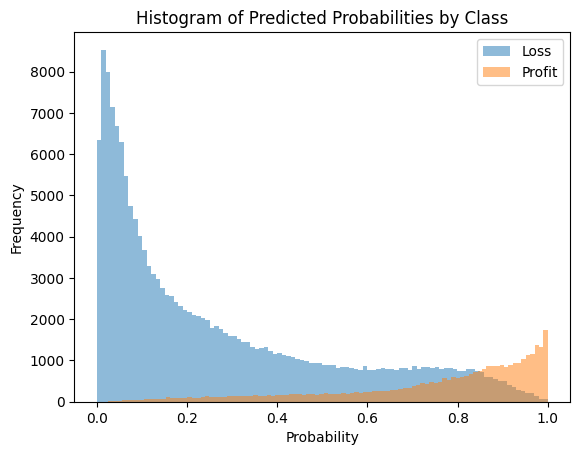

In [14]:
plt.hist(probs[np.where(y_test == 0)[0]], bins=100, alpha=0.5, label='Loss')
plt.hist(probs[np.where(y_test == 1)[0]], bins=100, alpha=0.5, label='Profit')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Predicted Probabilities by Class')
plt.legend()
plt.show()

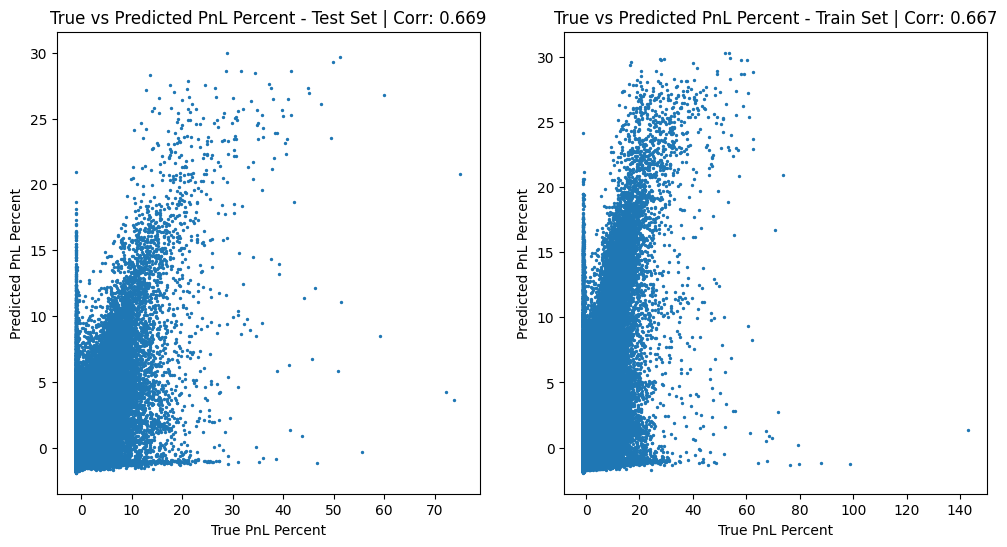

In [15]:
fig, axs = plt.subplots(1, 2, figsize = (12, 6))
test_corr = np.corrcoef(y_reg_test, y_reg_pred)[0, 1]
axs[0].scatter(invert_reg_scale(y_reg_test, denom_reg_scale, min_reg_scale),
               invert_reg_scale(y_reg_pred, denom_reg_scale, min_reg_scale), s = 2)
axs[0].set_xlabel('True PnL Percent')
axs[0].set_ylabel('Predicted PnL Percent')
axs[0].set_title(f'True vs Predicted PnL Percent - Test Set | Corr: {test_corr:.3f}')

logits = model(torch.from_numpy(X_train).to(device))[:, 1].detach().cpu().numpy()
train_corr = np.corrcoef(y_reg_train, logits)[0, 1]
axs[1].scatter(invert_reg_scale(y_reg_train, denom_reg_scale, min_reg_scale),
               invert_reg_scale(logits, denom_reg_scale, min_reg_scale), s = 2)
axs[1].set_xlabel('True PnL Percent')
axs[1].set_ylabel('Predicted PnL Percent')
axs[1].set_title(f'True vs Predicted PnL Percent - Train Set | Corr: {train_corr:.3f}')
plt.show()

In [16]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

206594